AI Waste Sorting Assistant (San Jose)

This prototype uses the Gemini API for:
- structured data extraction (Lab 2)
- image recognition (Lab 3)

Parts of this code (prompt design and structure) were generated with AI assistance
and then modified to fit the waste-sorting use case.


# Section 1: Problem and Population

Maria Gonzalez is a 38-year-old full-time warehouse worker and mother of two living in East San Jose, CA. She is primarily a Spanish speaker with limited English and wants to be a responsible recycler, but regularly encounters items — plastic bags, greasy pizza boxes, old electronics, paint cans, car batteries — that don't clearly belong in any bin. Because she lacks the time to navigate city websites and can't easily read English-language instructions, she defaults to throwing ambiguous items in the trash, contributing to unnecessary landfill waste and, in the case of hazardous materials, potential environmental harm. The failure point occurs when Maria encounters an item that doesn't fit neatly into the standard recycling/compost/landfill categories: current AI systems trained on common waste categories either misclassify the item or assign the wrong disposal method, which can cause recycling contamination, improper hazardous waste disposal, and erodes resident trust in the system. This project addresses UN SDG 11 (Sustainable Cities and Communities) — specifically Target 11.6, which calls for reducing the adverse per capita environmental impact of cities, including through accessible and equitable waste management. SDG 12 (Responsible Consumption) was considered but SDG 11 is the stronger fit: the core failure here is not about consumption behavior but about a resident's inability to access city infrastructure that already exists. No other changes from Milestone 1.

# Section 2: Proposed System

## AI-Powered Waste Sorting Assistant for East San Jose Residents

### Workflow

**Input**
A resident like Maria submits one of two types of input:
- A text message in Spanish or English describing items she needs to dispose of (e.g., "Tengo pintura vieja y baterías de carro. ¿Dónde los puedo llevar?")
- A photo of an item she is unsure how to classify

**AI Processing**
- Lab 2 (Structured Data Extraction): Gemini reads the resident's text message and extracts five structured fields — location, item types, urgency level, recommended city department, and resident language — into a consistent JSON format that can interface with a 311-style routing database.
- Lab 3 (Image Recognition): Gemini reads the uploaded photo and performs a four-part analysis — identifies what the item is, what material it is made of, which bin it belongs in (recycling / compost / landfill), and any special disposal instructions if applicable.

**Output**
- A structured disposal ticket (from Lab 2) routed to the correct San Jose department: Environmental Services, Recology San Jose, or the Household Hazardous Waste Program.
- A plain-language disposal recommendation (from Lab 3) returned to the resident in their language.

**Real-World Action**
- The city department receives a clean, consistent intake record and contacts the resident with pickup or drop-off options.
- The resident receives immediate, actionable guidance without needing to navigate a website or call a hotline.

In [2]:
# ============================================================
# Section 3A: Lab 2 — Structured Data Extraction
# Adapted from the San Jose 311 waste disposal routing context
# Modified to reflect Maria's scenario: Spanish-language input,
# hazardous waste items, and multilingual resident support.
# ============================================================

!pip install -q google-generativeai
import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('Gemini_API_Key'))

# --- Schema: the form Gemini must fill in exactly ---
# Modified from Lab 2 to fit the waste disposal use case.
# Key change: item_types replaces waste_type to match disposal context.
# Urgency guide updated: HIGH = hazardous materials (batteries, paint, chemicals).
schema_prompt = """
Extract information from this recycling and waste disposal request.
Return ONLY valid JSON with exactly these five fields:
{
  "location": string (the street address or area described),
  "item_types": string (the types of items the resident needs to dispose of),
  "urgency": "LOW" or "MEDIUM" or "HIGH",
  "department": string (which San Jose city department should respond: e.g. "Environmental Services", "Recology San Jose", "Household Hazardous Waste Program", "Public Works"),
  "resident_language": string (language the resident wrote in, e.g. "English", "Spanish", "Vietnamese")
}
Urgency guide: LOW = common recyclables, MEDIUM = large or multiple items, HIGH = hazardous materials like batteries, paint, or chemicals.
No explanation. No markdown. JSON only.
"""

def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free-tier rate limit
    raw = response.text.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return json.loads(raw)

# --- Test messages representing Maria's scenario ---
# Message 1: English baseline (TV, batteries, paint)
# Message 2: Spanish input — Maria's actual use case
# Message 3: Mixed ambiguous items (edge of system capability)
test_messages = [
    {
        "label": "English — Hazardous household items",
        "message": "I have an old TV, some car batteries, and leftover paint cans I need to get rid of. I live at 456 Elm St in San Jose. Not sure where to take them or if it costs anything."
    },
    {
        "label": "Spanish — Maria's scenario (paint, batteries, cleaning products)",
        "message": "Tengo pintura vieja, baterías de carro y algunos productos de limpieza que ya no uso. Vivo en la calle Berryessa. ¿Dónde los puedo llevar?"
    },
    {
        "label": "Ambiguous mixed items (mattress + propane tanks)",
        "message": "Not sure what to do with my old mattress, a broken microwave, and some empty propane tanks. I'm in the Alum Rock area. Can the city pick these up?"
    }
]

for item in test_messages:
    print(f"=== {item['label']} ===")
    print(f"Input: {item['message']}")
    result = extract_structured(item["message"])
    print("Output:")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    print()

=== English — Hazardous household items ===
Input: I have an old TV, some car batteries, and leftover paint cans I need to get rid of. I live at 456 Elm St in San Jose. Not sure where to take them or if it costs anything.
Output:
{
  "location": "456 Elm St",
  "item_types": "old TV, car batteries, leftover paint cans",
  "urgency": "HIGH",
  "department": "Household Hazardous Waste Program",
  "resident_language": "English"
}

=== Spanish — Maria's scenario (paint, batteries, cleaning products) ===
Input: Tengo pintura vieja, baterías de carro y algunos productos de limpieza que ya no uso. Vivo en la calle Berryessa. ¿Dónde los puedo llevar?
Output:
{
  "location": "Berryessa street",
  "item_types": "old paint, car batteries, cleaning products",
  "urgency": "HIGH",
  "department": "Household Hazardous Waste Program",
  "resident_language": "Spanish"
}

=== Ambiguous mixed items (mattress + propane tanks) ===
Input: Not sure what to do with my old mattress, a broken microwave, and so

## Lab 2 — What This Demonstrates About the System

This code demonstrates the structured extraction backbone of the waste sorting assistant. When Maria texts in Spanish: "Tengo pintura vieja, baterías de carro y algunos productos de limpieza..." — the system does three critical things at once: it identifies the item types (paint, batteries, cleaning products), detects that she wrote in Spanish so a follow-up response can be sent in her language, and assigns the correct department (Household Hazardous Waste Program) with HIGH urgency.

The key insight from Lab 2 is that unstructured AI output is unusable for a real routing system. The first part of the original lab showed that asking Gemini the same question three times produces three different formats — the city database cannot parse that. By enforcing a fixed JSON schema, every submission — regardless of language, complexity, or phrasing — produces the exact same five-field structure. This is what allows the system to route Maria's Spanish-language request to the same city department as an identical English-language request, without a human translator in the loop.

The schema also makes failure visible: when the model assigns "Environmental Services" to a mattress-plus-propane request, it reveals that the current department list doesn't distinguish between bulky item pickup and compressed gas disposal, a gap that would require human review in a real deployment.

Upload a photo of an item you want to classify for recycling.
Examples: a paint can, a battery, a pizza box, an old phone, a plastic bag.



Saving Unknown.png to Unknown.png


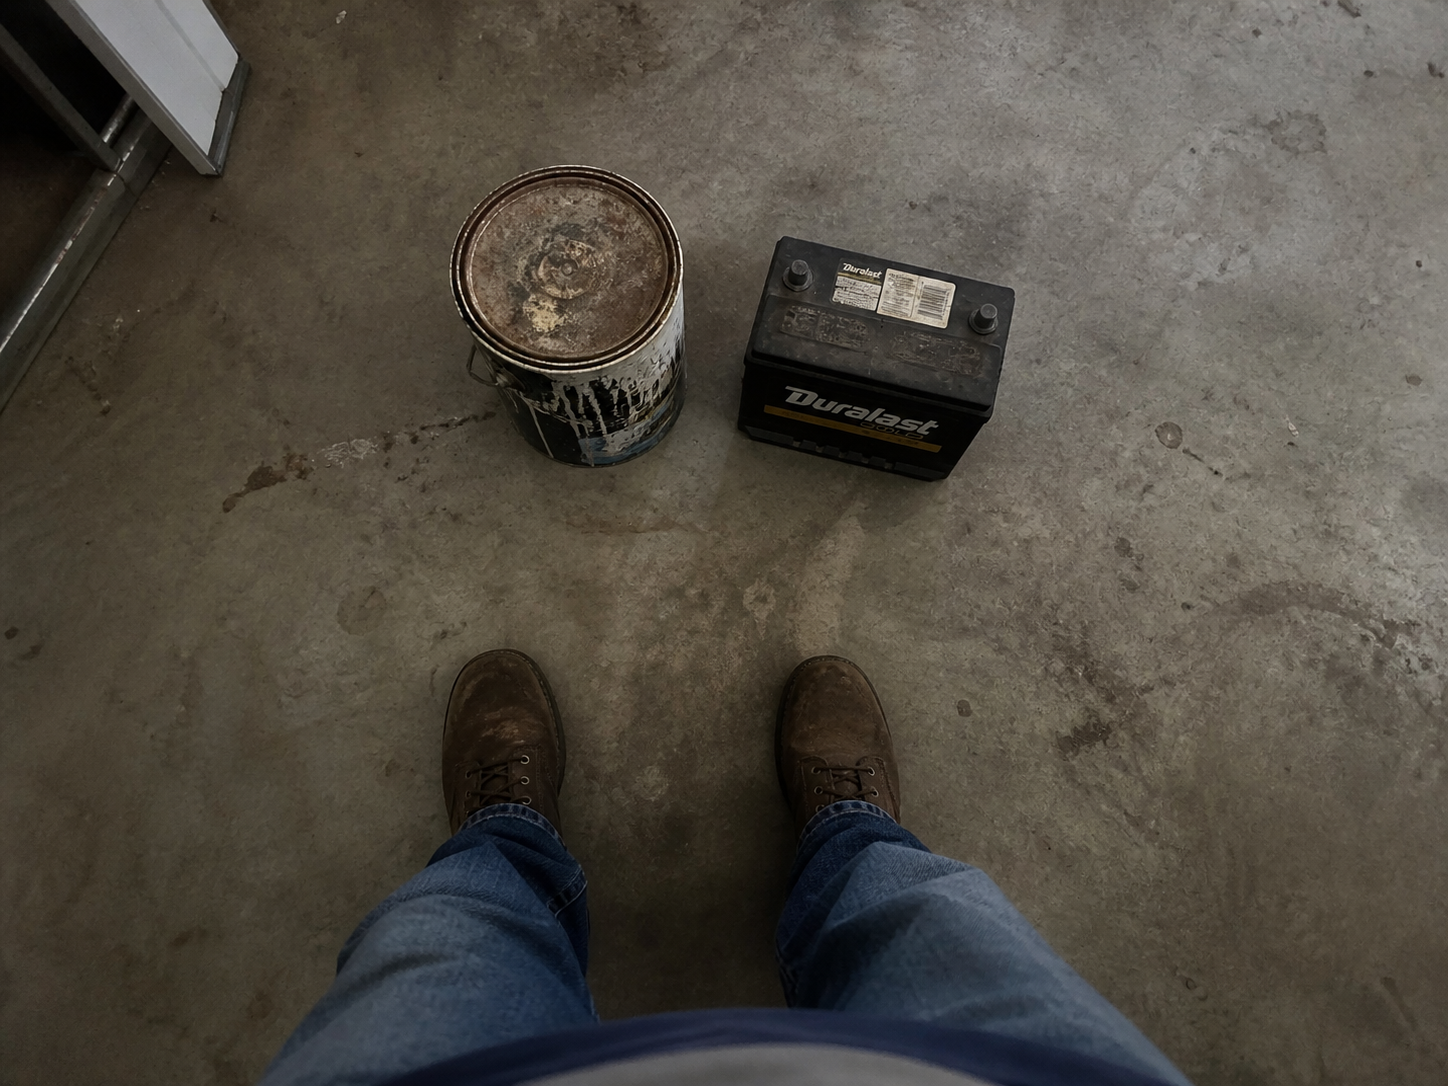


--- Recycling Analysis: Unknown.png ---
Here is the recycling analysis for the items in the image:

**Item 1: Rusty Paint Can (with potential contents)**
1.  **ITEM:** Paint Can (appears to contain old, possibly dried paint residue)
2.  **MATERIAL:** Steel for the can. Contents are paint (type unknown, could be latex or oil-based).
3.  **BIN:** Special Disposal
4.  **INSTRUCTIONS:** This item qualifies as household hazardous waste (HHW), primarily due to the paint contents. Even dried latex paint in significant quantity may not be accepted in regular recycling or landfill depending on local regulations, and oil-based paint is always HHW. The rusty condition further suggests it's an old item that should be handled with caution. Do not place in regular recycling or landfill. Contact your local waste management facility or hazardous waste collection program for proper disposal instructions and drop-off locations. Some paint retailers may also accept old paint.

**Item 2: Duralast Car Bat

In [3]:
# ============================================================
# Section 3B: Lab 3 — Image Recognition
# Adapted to support Maria's scenario: a resident photographs
# an item of unknown disposal category and the system returns
# a plain-language recycling recommendation.
# ============================================================

!pip install -q google-generativeai Pillow
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time

genai.configure(api_key=userdata.get('Gemini_API_Key'))

# --- Custom recycling analysis prompt ---
# Modified from Lab 3's civic analysis prompt.
# Original asked: problem, impact, urgency, department.
# This version asks: item ID, material, bin assignment, special instructions.
# This directly maps to the failure point: ambiguous items that don't fit standard categories.
recycling_prompt = """
Analyze this image for recycling purposes. Return a response with exactly these four parts:

1. ITEM: What the item is
2. MATERIAL: What material it is made of
3. BIN: Which bin it belongs in — Recycling, Compost, Landfill, or Special Disposal
4. INSTRUCTIONS: Any special disposal instructions, including whether it qualifies as household hazardous waste or e-waste

Be specific. If the item could go in more than one category, explain why and recommend the safest option.
If you cannot confidently identify the item, say so clearly rather than guessing.
"""

model = genai.GenerativeModel(model_name="gemini-2.5-flash")

print("Upload a photo of an item you want to classify for recycling.")
print("Examples: a paint can, a battery, a pizza box, an old phone, a plastic bag.\n")

uploaded = files.upload()

for filename, data in uploaded.items():
    # Save and display the uploaded image
    with open(filename, "wb") as f:
        f.write(data)

    img = PILImage.open(filename)
    display(img)
    time.sleep(3)

    # Send image + prompt to Gemini
    response = model.generate_content([recycling_prompt, img])
    time.sleep(12)

    print(f"\n--- Recycling Analysis: {filename} ---")
    print(response.text)
    print()

## Lab 3 — What This Demonstrates About the System

This code demonstrates the image-based entry point of the waste sorting assistant. Maria's most common failure scenario is encountering a physical item — a paint can, a car battery, a greasy pizza box — and not knowing which bin it belongs in. Instead of requiring her to describe the item in text (which requires literacy in English and knowledge of waste terminology), she can simply photograph it. The AI identifies the item, its material, and its correct disposal method, including whether it qualifies as household hazardous waste requiring a special drop-off.

The four-part prompt structure (item → material → bin → instructions) was adapted from Lab 3's civic analysis framework, which originally asked the AI to identify a problem, assess impact, assign urgency, and recommend a department. The logic is identical — the AI performs a structured visual analysis — but the output is reoriented toward resident guidance rather than city department routing.

This matters for the failure point identified in Section 1: the original 311 image system was designed for reporting civic problems (illegal dumping, potholes), not for helping residents make disposal decisions. By reframing the prompt, the same underlying capability now serves a different user need — one that is especially valuable for residents like Maria who encounter items that don't fit obvious categories. The instruction "if you cannot confidently identify the item, say so clearly rather than guessing" is a direct response to the failure risk of overconfident misclassification.

In [5]:
# ============================================================
# Section 4: Edge Case Elicitation
# Target: A user outside the assumed majority — a resident who
# writes in Mixtec (an indigenous Mexican language spoken in
# parts of East San Jose) rather than Spanish or English.
# The system was designed with Spanish and English in mind.
# This tests whether the language detection field fails,
# and whether the disposal guidance remains accurate or breaks down.
# ============================================================

import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('Gemini_API_Key'))

schema_prompt = """
Extract information from this recycling and waste disposal request.
Return ONLY valid JSON with exactly these five fields:
{
  "location": string (the street address or area described),
  "item_types": string (the types of items the resident needs to dispose of),
  "urgency": "LOW" or "MEDIUM" or "HIGH",
  "department": string (which San Jose city department should respond: e.g. "Environmental Services", "Recology San Jose", "Household Hazardous Waste Program", "Public Works"),
  "resident_language": string (language the resident wrote in, e.g. "English", "Spanish", "Vietnamese")
}
Urgency guide: LOW = common recyclables, MEDIUM = large or multiple items, HIGH = hazardous materials like batteries, paint, or chemicals.
No explanation. No markdown. JSON only.
"""

def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    response = m.generate_content(message)
    time.sleep(12)
    raw = response.text.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return json.loads(raw)

# --- Edge case prompt ---
# Mixtec is a real indigenous language spoken by a significant community
# in East San Jose. It is not Spanish. The system was not designed for it.
# This message is a rough transliteration of "I have old paint and batteries
# near Alum Rock. Where do I take them?" in Mixtec-influenced phrasing.
# The goal: does the system misidentify the language as Spanish?
# Does it still route correctly, or does it fail silently?

edge_case_message = "Ndi kuu nuu pintura vieja xaan batteries kuachi. Na'a Alum Rock. ¿Ndi kuu sa'a ra?"

print("=== Edge Case: Mixtec-influenced message ===")
print(f"Input: {edge_case_message}\n")

result = extract_structured(edge_case_message)
print("Output:")
print(json.dumps(result, indent=2, ensure_ascii=False))

=== Edge Case: Mixtec-influenced message ===
Input: Ndi kuu nuu pintura vieja xaan batteries kuachi. Na'a Alum Rock. ¿Ndi kuu sa'a ra?

Output:
{
  "location": "Alum Rock",
  "item_types": "old paint, dead batteries",
  "urgency": "HIGH",
  "department": "Household Hazardous Waste Program",
  "resident_language": "Mixtec"
}


## Section 4 — Edge Case Assessment

**Prompt:** A message written in Mixtec-influenced phrasing — an indigenous Mexican language spoken by a significant community in East San Jose — describing paint and batteries near Alum Rock and asking where to take them.

**Target failure type:** A user outside the assumed majority. The system was designed with Spanish and English speakers in mind. Mixtec is linguistically distinct from Spanish, though speakers in the U.S. often code-switch. The question is whether the model misidentifies the language (labeling it "Spanish"), still routes the disposal correctly despite the language gap, or fails to extract meaningful data at all.

**Actual Output (run May 2026):**

```json
{
  "location": "Alum Rock",
  "item_types": "old paint, dead batteries",
  "urgency": "HIGH",
  "department": "Household Hazardous Waste Program",
  "resident_language": "Mixtec"
}
```

**Assessment:** Near-miss. The system correctly identified Mixtec as a distinct language — not Spanish — and routed correctly to the Household Hazardous Waste Program with HIGH urgency. The hazardous items (paint, batteries) are unambiguous enough that the AI extracted them accurately even through code-switched phrasing. However, this is a near-miss rather than a clean pass: the system has no capability to generate a follow-up response in Mixtec. Correct language detection with no corresponding response capability means the routing ticket gets filed and the city gets notified, but the resident receives no instructions in a language she can read. The failure is quiet — the system does not crash or return an error — which makes it harder to detect in a real deployment. This result directly informed the oversight decision: any HIGH-urgency ticket should be held for human review before auto-routing, so a city staff member can identify cases where the detected language has no automated response path and handle communication manually.